<a href="https://colab.research.google.com/github/livaage/nsbi-lhc-toolkit/blob/ml4hep-tifr-colab/workshops/ml4hep_tifr_colab/Exercise_3_normalizing_flows_density_estimation_direct_likelihood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3 — Direct density estimation with normalizing flows

**Google Colab fallback.** Run the setup cell below **first** — it installs the
dependencies, pulls the `nsbi_common_utils` package plus the tutorial helpers
(`utils.py`, `generate_distributions.py`), generates the dataset, and moves into
the tutorial directory so everything below runs unchanged.

> 💡 For the training notebooks, switch to a **GPU runtime**
> (*Runtime → Change runtime type → GPU*) and consider lowering `number_of_epochs`
> / `N_TRAIN` for a quick pass.


In [ ]:
# ============================================================================
# Google Colab setup — run me first.  Safe to re-run; a no-op off Colab.
# ============================================================================
import os, sys

# --- config -----------------------------------------------------------------
REPO_URL = "https://github.com/livaage/nsbi-lhc-toolkit.git"  # package + tutorial helpers
BRANCH   = "ml4hep_school_tutorial"
N_BKG, N_SIG = 300_000, 300_000     # Colab-sized dataset (raise for less MC noise in the fit)
USE_DRIVE = False                   # True -> save data/models to Google Drive so they
                                    # persist across notebooks & sessions (see notes above)
# ----------------------------------------------------------------------------

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = "/content/drive/MyDrive/ml4hep_tifr_colab"
    else:
        ROOT = "/content"
    os.makedirs(ROOT, exist_ok=True)
    os.chdir(ROOT)

    # 1) fetch ONLY the package source + tutorial helpers (skip Git-LFS / big blobs)
    if not os.path.isdir("nsbi-lhc-toolkit"):
        os.environ["GIT_LFS_SKIP_SMUDGE"] = "1"
        !git clone --depth 1 --filter=blob:none --sparse --branch $BRANCH $REPO_URL
        !cd nsbi-lhc-toolkit && git sparse-checkout set src workshops/ml4hep_tifr

    # 2) make `import nsbi_common_utils` work (pure-python src layout, no build step)
    src = os.path.abspath("nsbi-lhc-toolkit/src")
    if src not in sys.path:
        sys.path.insert(0, src)

    # 3) runtime deps Colab doesn't already ship (torch/jax/sklearn/... are preinstalled)
    !pip install -q pytorch-lightning onnx onnxruntime onnxscript iminuit mplhep

    # 4) work from the tutorial dir so utils.py / generate_distributions.py and the
    #    ./dataframes, ./models_* relative paths resolve just like a local run
    os.chdir("nsbi-lhc-toolkit/workshops/ml4hep_tifr")

    # 5) generate the Gaussian-mixture samples if they aren't there yet
    if not os.path.exists("dataframes/signal.parquet"):
        !python generate_distributions.py --n_bkg $N_BKG --n_sig $N_SIG

print("Working dir:", os.getcwd())


# Exercise 3 — Direct density estimation with normalizing flows

In the previous exercises we estimated density ratios directly with classifiers.  Here we do a complementary exercise: train two normalizing flows,

$$
\hat p_\mathrm{sig}(x), \qquad \hat p_\mathrm{bkg}(x),
$$

where $x=(x_1,\ldots,x_5)$ are the reconstructed/smeared features.  We then:

1. train one binary-mask RealNVP flow for the background and one for the signal;
2. validate the learned densities against MC projections and, for this toy problem, the analytic smeared Gaussian-mixture truth;
3. build the likelihood **directly from the densities**, without forming density ratios and without constructing a workspace;
4. fit the signal-strength parameter $\mu$ with a small JAX likelihood;
5. use the explicit toy density to generate pseudo-experiments and visualize the distribution of the likelihood-ratio test statistic.

The main pedagogical contrast is:

- classifier method: learn $p_i(x)/p_\mathrm{ref}(x)$ directly;
- flow method: learn $p_i(x)$ directly and insert those densities in the likelihood.


## Inputs expected by this notebook

This notebook expects the updated generator output:

```text
dataframes/background.parquet
dataframes/signal.parquet
```

with both truth-level columns `z1,...,z5` and reco-level columns `x1,...,x5`.  The fit below uses only the reco-level `x*` variables.

In [1]:
import math
import os
from dataclasses import dataclass
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import logsumexp
from scipy.stats import multivariate_normal

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import nsbi_common_utils

from utils import (
    FEATURES,
    background_components,
    signal_components,
    smearing_parameters,
    split_train_inference,
)

FEATURES = list(FEATURES)
N_DIM = len(FEATURES)

SEED = 12345
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Features: {FEATURES}")


Using device: cpu
Features: ['x1', 'x2', 'x3', 'x4', 'x5']


In [2]:
BASE_PATH = Path("./dataframes")
FLOW_MODEL_DIR = Path("models_flows")
DENSITY_DIR = Path("saved_densities_flows")
PLOT_DIR = Path("plots_flows")

for directory in [FLOW_MODEL_DIR, DENSITY_DIR, PLOT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Must match the density-ratio training/fitting notebooks if you want disjoint
# train/inference samples across all approaches.
SPLIT_SEED = 0
TRAIN_FRACTION = 0.5

# Keep these modest for a tutorial.  Increase N_EPOCHS and MAX_TRAIN_EVENTS
# for tighter closure against the analytic truth.
MAX_TRAIN_EVENTS = {
    "background": 2_500_000,
    "signal": 2_500_000,
}

N_COUPLING_LAYERS = 8
HIDDEN_FEATURES = 128
HIDDEN_LAYERS = 2
BATCH_SIZE = 2048
N_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-6
VALIDATION_FRACTION = 0.20
PATIENCE = 5

# If checkpoints already exist, load them instead of retraining.
LOAD_IF_AVAILABLE = True


## Load data and make the same train/inference split

The flows are trained on the training half.  The likelihood fit is evaluated on the inference half.  This mirrors the density-ratio notebooks and avoids using the same events to learn and evaluate the likelihood.

In [3]:
signal = pd.read_parquet(BASE_PATH / "signal.parquet")
background = pd.read_parquet(BASE_PATH / "background.parquet")

missing = [f for f in FEATURES if f not in signal.columns or f not in background.columns]
if missing:
    raise RuntimeError(
        "Missing reco-level columns "
        f"{missing}. Regenerate the parquet files with the updated generator "
        "that writes x1,...,x5."
    )

for name, df in [("signal", signal), ("background", background)]:
    if "weight" not in df.columns:
        raise RuntimeError(f"{name} dataframe is missing a 'weight' column.")
    print(
        f"{name:10s}: {len(df):,} events, "
        f"sum weights = {df['weight'].sum():.6g}"
    )

signal    : 5,000,000 events, sum weights = 1100
background: 5,000,000 events, sum weights = 1e+06


In [4]:
signal_train, _ = split_train_inference(
    signal, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED
)
background_train, _ = split_train_inference(
    background, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED
)

TOTAL_YIELD = {
    "signal": float(signal_train["weight"].sum()),
    "background": float(background_train["weight"].sum()),
}

# Let's use the same sample to train and eval.
# This should not be done in real life
signal_eval = signal_train
background_eval = background_train

print(f"Flow training: {len(signal_train):,} signal + {len(background_train):,} background events")
print(f"Fit/eval:      {len(signal_eval):,} signal + {len(background_eval):,} background events")
print(TOTAL_YIELD)

Flow training: 2,500,000 signal + 2,500,000 background events
Fit/eval:      2,500,000 signal + 2,500,000 background events
{'signal': 1099.9999999999918, 'background': 1000000.0000000072}


## A minimal RealNVP density estimator

This is a deliberately compact RealNVP implementation.  Each affine-coupling layer uses a fixed binary mask, alternating which coordinates are transformed.  We train by maximizing the exact log likelihood

$$
\log \hat p(x) = \log p_Z\big(f(x)\big) + \log\left|\det\frac{\partial f}{\partial x}\right|.
$$

For numerical stability, each sample is standardized before training.  The final `flow_log_prob_x` helper below adds the standardization Jacobian back, so it returns a density in the original `x` coordinates.

In [5]:
@dataclass
class Standardizer:
    mean: np.ndarray
    std: np.ndarray

    @classmethod
    def fit(cls, x):
        x = np.asarray(x, dtype=np.float32)
        mean = x.mean(axis=0).astype(np.float32)
        std = x.std(axis=0).astype(np.float32)
        std = np.where(std > 1e-6, std, 1.0).astype(np.float32)
        return cls(mean=mean, std=std)

    def transform(self, x):
        x = np.asarray(x, dtype=np.float32)
        return ((x - self.mean) / self.std).astype(np.float32)

    def inverse(self, z):
        z = np.asarray(z, dtype=np.float32)
        return (z * self.std + self.mean).astype(np.float32)

    @property
    def log_det_x_to_z_standardization(self):
        # z = (x - mean) / std, so log |dz/dx| = -sum(log std)
        return float(-np.log(self.std).sum())


class MLP(nn.Module):
    def __init__(self, n_in, n_out, hidden_features=128, hidden_layers=2):
        super().__init__()
        layers = []
        last = n_in
        for _ in range(hidden_layers):
            layers.extend([nn.Linear(last, hidden_features), nn.ReLU()])
            last = hidden_features
        layers.append(nn.Linear(last, n_out))
        self.net = nn.Sequential(*layers)

        # Start each coupling layer close to the identity map.
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)


class AffineCoupling(nn.Module):
    def __init__(self, n_features, mask, hidden_features=128, hidden_layers=2, scale_clip=1.5):
        super().__init__()
        self.register_buffer("mask", torch.as_tensor(mask, dtype=torch.float32))
        self.net = MLP(
            n_features,
            2 * n_features,
            hidden_features=hidden_features,
            hidden_layers=hidden_layers,
        )
        self.scale_clip = float(scale_clip)

    def _shift_and_log_scale(self, x_masked):
        shift, log_scale = self.net(x_masked).chunk(2, dim=-1)
        inv_mask = 1.0 - self.mask
        log_scale = self.scale_clip * torch.tanh(log_scale) * inv_mask
        shift = shift * inv_mask
        return shift, log_scale

    def forward(self, x):
        """Map data space -> base space for this layer."""
        x_masked = x * self.mask
        shift, log_scale = self._shift_and_log_scale(x_masked)
        z = x_masked + (1.0 - self.mask) * (x - shift) * torch.exp(-log_scale)
        log_det = -log_scale.sum(dim=-1)
        return z, log_det

    def inverse(self, z):
        """Map base space -> data space for this layer."""
        z_masked = z * self.mask
        shift, log_scale = self._shift_and_log_scale(z_masked)
        x = z_masked + (1.0 - self.mask) * (z * torch.exp(log_scale) + shift)
        log_det = log_scale.sum(dim=-1)
        return x, log_det


class RealNVP(nn.Module):
    def __init__(
        self,
        n_features,
        n_coupling_layers=8,
        hidden_features=128,
        hidden_layers=2,
    ):
        super().__init__()
        base_mask = torch.tensor(
            [(i % 2) for i in range(n_features)], dtype=torch.float32
        )
        masks = [base_mask if i % 2 == 0 else 1.0 - base_mask for i in range(n_coupling_layers)]
        self.layers = nn.ModuleList(
            [
                AffineCoupling(
                    n_features=n_features,
                    mask=mask,
                    hidden_features=hidden_features,
                    hidden_layers=hidden_layers,
                )
                for mask in masks
            ]
        )
        self.n_features = int(n_features)

    def log_prob(self, x):
        z = x
        total_log_det = torch.zeros(x.shape[0], device=x.device)
        for layer in self.layers:
            z, log_det = layer(z)
            total_log_det = total_log_det + log_det
        base_log_prob = -0.5 * (z.pow(2) + math.log(2.0 * math.pi)).sum(dim=-1)
        return base_log_prob + total_log_det

    @torch.no_grad()
    def sample(self, n):
        z = torch.randn(n, self.n_features, device=next(self.parameters()).device)
        x = z
        for layer in reversed(self.layers):
            x, _ = layer.inverse(x)
        return x

## Training helpers

The `train_flow` helper saves checkpoints under `models_flows/`.  Re-running the notebook will load existing checkpoints unless `LOAD_IF_AVAILABLE = False`.

In [6]:
def model_config():
    return {
        "n_features": N_DIM,
        "n_coupling_layers": N_COUPLING_LAYERS,
        "hidden_features": HIDDEN_FEATURES,
        "hidden_layers": HIDDEN_LAYERS,
    }


def build_flow():
    return RealNVP(**model_config()).to(device)


def checkpoint_path(sample_name):
    return FLOW_MODEL_DIR / f"realnvp_{sample_name}.pt"


def _torch_load(path):
    # PyTorch versions differ in whether torch.load exposes weights_only.
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def save_flow(sample_name, flow, scaler):
    path = checkpoint_path(sample_name)
    torch.save(
        {
            "state_dict": flow.state_dict(),
            "scaler_mean": scaler.mean,
            "scaler_std": scaler.std,
            "features": FEATURES,
            "config": model_config(),
        },
        path,
    )
    return path


def load_flow(sample_name):
    path = checkpoint_path(sample_name)
    ckpt = _torch_load(path)
    flow = RealNVP(**ckpt["config"]).to(device)
    flow.load_state_dict(ckpt["state_dict"])
    flow.eval()
    scaler = Standardizer(
        mean=np.asarray(ckpt["scaler_mean"], dtype=np.float32),
        std=np.asarray(ckpt["scaler_std"], dtype=np.float32),
    )
    return {"flow": flow, "scaler": scaler, "path": path}


def choose_training_array(df, sample_name, seed):
    n_max = MAX_TRAIN_EVENTS.get(sample_name)
    if n_max is not None and len(df) > n_max:
        df = df.sample(n=n_max, random_state=seed).reset_index(drop=True)
    return df[FEATURES].to_numpy(dtype=np.float32)


def make_loaders(x_scaled, seed):
    x_tensor = torch.tensor(x_scaled, dtype=torch.float32)
    n_total = len(x_tensor)
    n_val = max(1, int(round(VALIDATION_FRACTION * n_total)))
    n_train = n_total - n_val

    generator = torch.Generator().manual_seed(seed)
    permutation = torch.randperm(n_total, generator=generator)
    train_idx = permutation[:n_train]
    val_idx = permutation[n_train:]

    train_ds = TensorDataset(x_tensor[train_idx])
    val_ds = TensorDataset(x_tensor[val_idx])

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=False,
        generator=generator,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
    )
    return train_loader, val_loader


def train_flow(sample_name, df_train, seed=0):
    path = checkpoint_path(sample_name)
    if LOAD_IF_AVAILABLE and path.exists():
        print(f"Loading existing {sample_name} flow from {path}")
        return load_flow(sample_name)

    x = choose_training_array(df_train, sample_name=sample_name, seed=seed)
    scaler = Standardizer.fit(x)
    x_scaled = scaler.transform(x)
    train_loader, val_loader = make_loaders(x_scaled, seed=seed)

    flow = build_flow()
    optimizer = torch.optim.AdamW(
        flow.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )

    best_val = np.inf
    best_state = None
    stale_epochs = 0

    print(f"Training {sample_name} flow on {len(x_scaled):,} events")
    for epoch in range(1, N_EPOCHS + 1):
        flow.train()
        train_losses = []
        for (batch,) in train_loader:
            batch = batch.to(device)
            loss = -flow.log_prob(batch).mean()
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(flow.parameters(), max_norm=5.0)
            optimizer.step()
            train_losses.append(float(loss.detach().cpu()))

        flow.eval()
        val_losses = []
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(device)
                val_losses.append(float((-flow.log_prob(batch).mean()).detach().cpu()))
        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        print(f"  epoch {epoch:03d}: train NLL = {train_loss:.4f}, val NLL = {val_loss:.4f}")

        if val_loss < best_val - 1e-4:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in flow.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= PATIENCE:
                print(f"  early stopping after {epoch} epochs")
                break

    if best_state is not None:
        flow.load_state_dict(best_state)
    flow.eval()
    saved = save_flow(sample_name, flow, scaler)
    print(f"Saved {sample_name} flow to {saved}")
    return {"flow": flow, "scaler": scaler, "path": saved}

In [7]:
flows = {
    "background": train_flow("background", background_train, seed=101),
    "signal": train_flow("signal", signal_train, seed=202),
}

Loading existing background flow from models_flows/realnvp_background.pt
Loading existing signal flow from models_flows/realnvp_signal.pt


## Density and sampling helpers

`flow_log_prob_x` returns log densities in the original `x` coordinates, not standardized coordinates.

In [8]:
@torch.no_grad()
def flow_log_prob_x(flow_pack, x, batch_size=65_536):
    if isinstance(x, pd.DataFrame):
        x = x[FEATURES].to_numpy(dtype=np.float32)
    else:
        x = np.asarray(x, dtype=np.float32)

    flow = flow_pack["flow"]
    scaler = flow_pack["scaler"]
    flow.eval()

    chunks = []
    for start in range(0, len(x), batch_size):
        xb = scaler.transform(x[start:start + batch_size])
        xb = torch.tensor(xb, dtype=torch.float32, device=device)
        log_p_scaled = flow.log_prob(xb).detach().cpu().numpy()
        log_p_x = log_p_scaled + scaler.log_det_x_to_z_standardization
        chunks.append(log_p_x)
    return np.concatenate(chunks)


@torch.no_grad()
def flow_sample_x(flow_pack, n, batch_size=65_536):
    flow = flow_pack["flow"]
    scaler = flow_pack["scaler"]
    flow.eval()
    chunks = []
    remaining = int(n)
    while remaining > 0:
        m = min(batch_size, remaining)
        z = flow.sample(m).detach().cpu().numpy()
        chunks.append(scaler.inverse(z))
        remaining -= m
    return np.concatenate(chunks, axis=0)

## Validation 1: MC projection closure

Generate samples from the trained flow and compare one-dimensional projections with the held-out MC sample.  This is not a full high-dimensional validation, but it is an intuitive first check for students.

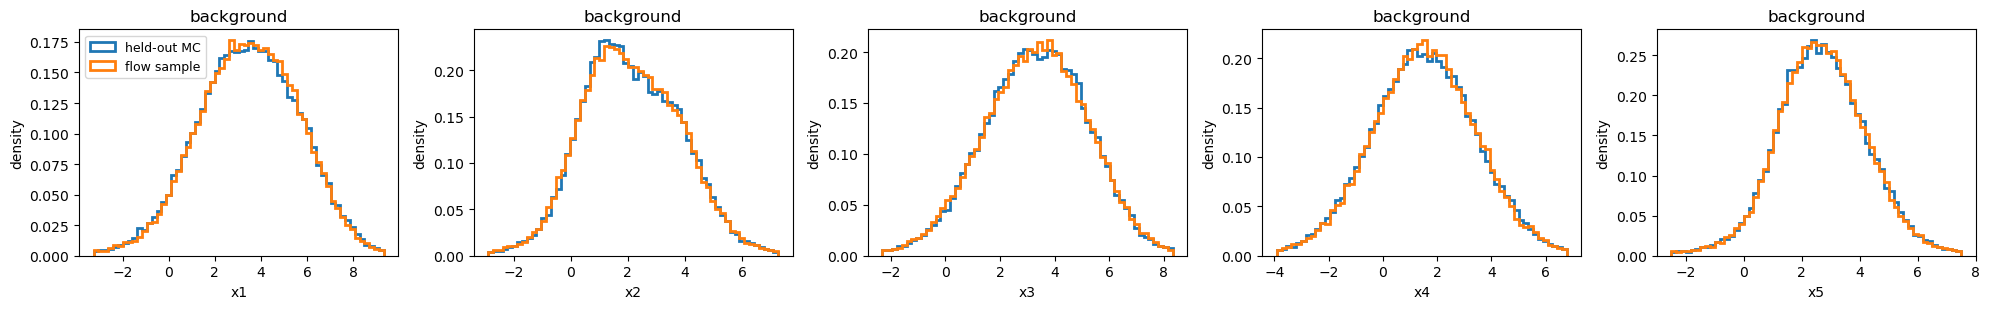

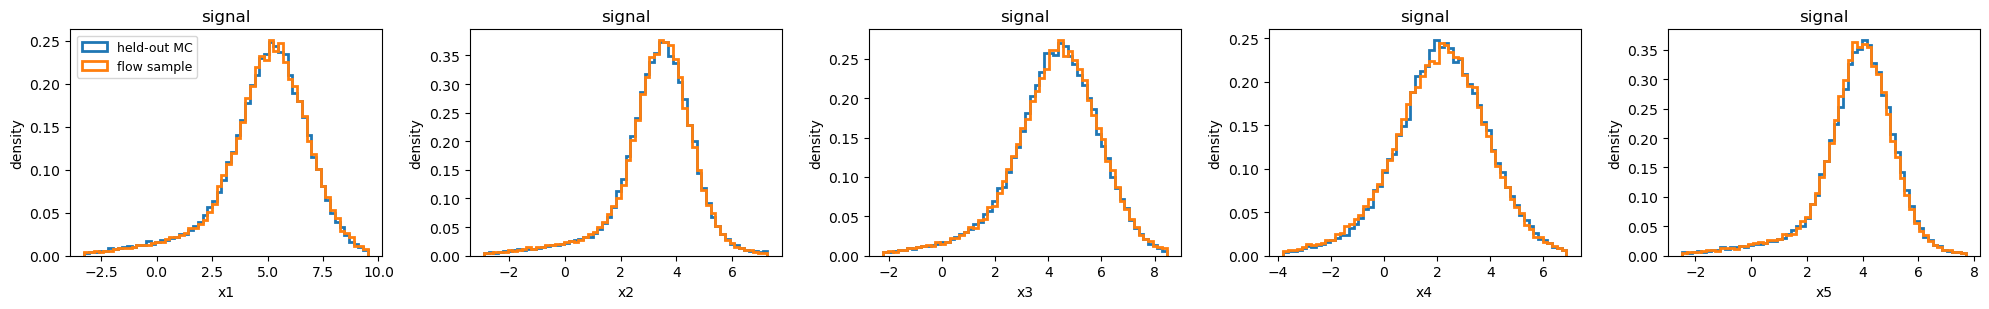

In [9]:
def plot_1d_flow_closure(sample_name, df_eval, flow_pack, n_plot=50_000, n_bins=60):
    n_plot = min(n_plot, len(df_eval))
    mc = df_eval.sample(n=n_plot, random_state=SEED)[FEATURES].to_numpy(dtype=np.float32)
    gen = flow_sample_x(flow_pack, n_plot)

    fig, axes = plt.subplots(1, len(FEATURES), figsize=(4.0 * len(FEATURES), 3.2))
    if len(FEATURES) == 1:
        axes = [axes]
    for j, (ax, feat) in enumerate(zip(axes, FEATURES)):
        lo, hi = np.quantile(mc[:, j], [0.005, 0.995])
        bins = np.linspace(lo, hi, n_bins + 1)
        ax.hist(mc[:, j], bins=bins, density=True, histtype="step", lw=2, label="held-out MC")
        ax.hist(gen[:, j], bins=bins, density=True, histtype="step", lw=2, label="flow sample")
        ax.set_xlabel(feat)
        ax.set_ylabel("density")
        ax.set_title(sample_name)
    axes[0].legend(fontsize=9)
    fig.tight_layout()
    return fig

fig = plot_1d_flow_closure("background", background_eval, flows["background"])
fig.savefig(PLOT_DIR / "background_flow_1d_closure.pdf", bbox_inches="tight")
plt.show()

fig = plot_1d_flow_closure("signal", signal_eval, flows["signal"])
fig.savefig(PLOT_DIR / "signal_flow_1d_closure.pdf", bbox_inches="tight")
plt.show()

## Validation 2: compare with the analytic smeared truth

For the generator, the truth-level variables are Gaussian mixtures in $y$.  The reco variables are generated as

$$
x = D y + \epsilon, \qquad \epsilon_i \sim \mathcal{N}(0, \sigma_{\mathrm{res},i}^2),
$$

where $D = \mathrm{diag}(\mathrm{scale})$.  Therefore each Gaussian component remains Gaussian after smearing:

$$
\mu_x = D\mu_y, \qquad \Sigma_x = D\Sigma_yD^T + \mathrm{diag}(\sigma_\mathrm{res}^2).
$$

This analytic truth is only available because the tutorial toy model is simple.  It is useful here as a clean closure check of the flow density itself.

In [10]:
def reco_components_from_truth_components(components):
    scale, resolution = smearing_parameters()
    scale = np.asarray(scale, dtype=float)
    resolution = np.asarray(resolution, dtype=float)
    D = np.diag(scale)
    response_cov = np.diag(resolution ** 2)

    reco_components = []
    for frac, mean_y, cov_y in components:
        mean_x = scale * np.asarray(mean_y, dtype=float)
        cov_x = D @ np.asarray(cov_y, dtype=float) @ D.T + response_cov
        reco_components.append((frac, mean_x, cov_x))
    return reco_components


def mixture_log_density(x, components):
    x = np.asarray(x, dtype=float)
    fracs = np.asarray([c[0] for c in components], dtype=float)
    fracs = fracs / fracs.sum()

    terms = []
    for f, (_, mean, cov) in zip(fracs, components):
        terms.append(
            np.log(f) + multivariate_normal(mean=mean, cov=cov, allow_singular=False).logpdf(x)
        )
    return logsumexp(np.vstack(terms), axis=0)


TRUTH_RECO_COMPONENTS = {
    "background": reco_components_from_truth_components(background_components()),
    "signal": reco_components_from_truth_components(signal_components()),
}

background: corr(log p) = 0.9985, RMSE = 0.1244, bias = -0.0056


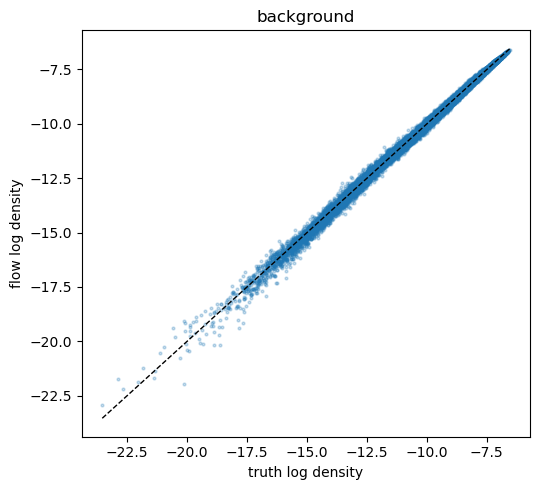

signal: corr(log p) = 0.9991, RMSE = 0.1084, bias = -0.0053


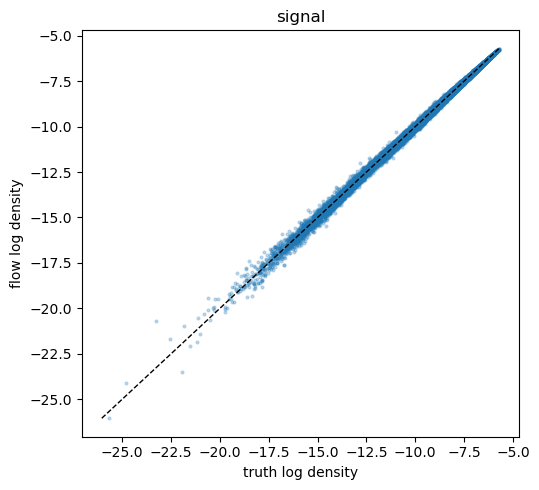

In [11]:
def compare_log_density_to_truth(sample_name, df_eval, flow_pack, n_points=25_000):
    n_points = min(n_points, len(df_eval))
    x = df_eval.sample(n=n_points, random_state=SEED)[FEATURES].to_numpy(dtype=np.float32)
    log_p_flow = flow_log_prob_x(flow_pack, x)
    log_p_truth = mixture_log_density(x, TRUTH_RECO_COMPONENTS[sample_name])
    delta = log_p_flow - log_p_truth

    corr = np.corrcoef(log_p_truth, log_p_flow)[0, 1]
    rmse = np.sqrt(np.mean(delta ** 2))
    bias = np.mean(delta)
    print(f"{sample_name}: corr(log p) = {corr:.4f}, RMSE = {rmse:.4f}, bias = {bias:.4f}")

    fig, ax = plt.subplots(figsize=(5.5, 5.0))
    ax.scatter(log_p_truth, log_p_flow, s=4, alpha=0.25)
    lo = min(log_p_truth.min(), log_p_flow.min())
    hi = max(log_p_truth.max(), log_p_flow.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel("truth log density")
    ax.set_ylabel("flow log density")
    ax.set_title(sample_name)
    fig.tight_layout()
    return fig

fig = compare_log_density_to_truth("background", background_eval, flows["background"])
fig.savefig(PLOT_DIR / "background_flow_logp_truth.pdf", bbox_inches="tight")
plt.show()

fig = compare_log_density_to_truth("signal", signal_eval, flows["signal"])
fig.savefig(PLOT_DIR / "signal_flow_logp_truth.pdf", bbox_inches="tight")
plt.show()

In [12]:
def compare_log_density_to_truth_binned(
    sample_name,
    df_eval,
    flow_pack,
    n_points=100_000,
    n_bins=25,
    binning="quantile",
    show_scatter=False,
):
    """Binned calibration curve for log p_flow against log p_truth."""

    n_points = min(n_points, len(df_eval))
    x = df_eval.sample(n=n_points, random_state=SEED)[FEATURES].to_numpy(dtype=np.float32)

    log_p_flow = flow_log_prob_x(flow_pack, x)
    log_p_truth = mixture_log_density(x, TRUTH_RECO_COMPONENTS[sample_name])
    delta = log_p_flow - log_p_truth

    if binning == "quantile":
        # Roughly equal statistics per bin.
        edges = np.quantile(log_p_truth, np.linspace(0.0, 1.0, n_bins + 1))
        edges = np.unique(edges)
    elif binning == "uniform":
        edges = np.linspace(log_p_truth.min(), log_p_truth.max(), n_bins + 1)
    else:
        edges = np.asarray(binning, dtype=float)

    if len(edges) < 3:
        raise ValueError("Need at least two non-empty bins for the calibration plot.")

    eps = 1.0e-9 * max(1.0, float(edges[-1] - edges[0]))
    edges = edges.astype(float).copy()
    edges[0] -= eps
    edges[-1] += eps

    bin_index = np.searchsorted(edges, log_p_truth, side="right") - 1
    bin_index = np.clip(bin_index, 0, len(edges) - 2)

    rows = []
    for i in range(len(edges) - 1):
        mask = bin_index == i
        count = int(mask.sum())

        if count == 0:
            rows.append(
                {
                    "bin": i,
                    "truth_lo": edges[i],
                    "truth_hi": edges[i + 1],
                    "count": count,
                    "truth_mean": np.nan,
                    "flow_mean": np.nan,
                    "flow_sem": np.nan,
                    "delta_mean": np.nan,
                    "delta_sem": np.nan,
                }
            )
            continue

        flow_std = log_p_flow[mask].std(ddof=1) if count > 1 else 0.0
        delta_std = delta[mask].std(ddof=1) if count > 1 else 0.0

        rows.append(
            {
                "bin": i,
                "truth_lo": edges[i],
                "truth_hi": edges[i + 1],
                "count": count,
                "truth_mean": log_p_truth[mask].mean(),
                "flow_mean": log_p_flow[mask].mean(),
                "flow_sem": flow_std / np.sqrt(count),
                "delta_mean": delta[mask].mean(),
                "delta_sem": delta_std / np.sqrt(count),
            }
        )

    calib = pd.DataFrame(rows)
    valid = calib["count"] > 0

    binned_bias = np.average(
        calib.loc[valid, "delta_mean"],
        weights=calib.loc[valid, "count"],
    )
    binned_rms = np.sqrt(
        np.average(
            calib.loc[valid, "delta_mean"] ** 2,
            weights=calib.loc[valid, "count"],
        )
    )
    max_abs_bias = np.nanmax(np.abs(calib.loc[valid, "delta_mean"]))

    print(
        f"{sample_name}: binned bias = {binned_bias:.4f}, "
        f"binned RMS bias = {binned_rms:.4f}, "
        f"max |bin bias| = {max_abs_bias:.4f}"
    )

    fig, (ax, rax) = plt.subplots(
        2,
        1,
        figsize=(6.4, 6.0),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )

    if show_scatter:
        ax.scatter(log_p_truth, log_p_flow, s=3, alpha=0.10)

    flow_step = calib["flow_mean"].to_numpy()
    delta_step = calib["delta_mean"].to_numpy()

    ax.step(
        edges,
        np.r_[flow_step, flow_step[-1]],
        where="post",
        lw=2,
        label="bin mean",
    )
    ax.errorbar(
        calib.loc[valid, "truth_mean"],
        calib.loc[valid, "flow_mean"],
        yerr=calib.loc[valid, "flow_sem"],
        fmt="o",
        ms=3,
        capsize=2,
    )

    lo = min(edges[0], np.nanmin(flow_step))
    hi = max(edges[-1], np.nanmax(flow_step))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect calibration")
    ax.set_ylabel(r"$\langle \log \hat p_{\rm flow} \rangle$")
    ax.set_title(f"{sample_name}: binned log-density calibration")
    ax.legend(fontsize=8)

    rax.step(
        edges,
        np.r_[delta_step, delta_step[-1]],
        where="post",
        lw=2,
    )
    rax.errorbar(
        calib.loc[valid, "truth_mean"],
        calib.loc[valid, "delta_mean"],
        yerr=calib.loc[valid, "delta_sem"],
        fmt="o",
        ms=3,
        capsize=2,
    )
    rax.axhline(0.0, color="k", lw=1)
    rax.set_xlabel(r"truth $\log p(x)$ bin")
    rax.set_ylabel(r"$\langle \Delta \log p \rangle$")
    rax.set_xlim(edges[0], edges[-1])

    return fig, calib

background: binned bias = -0.0067, binned RMS bias = 0.0290, max |bin bias| = 0.0845


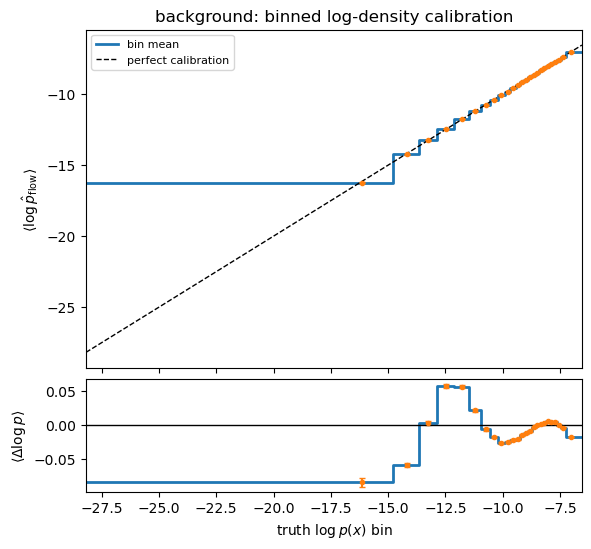

signal: binned bias = -0.0055, binned RMS bias = 0.0129, max |bin bias| = 0.0334


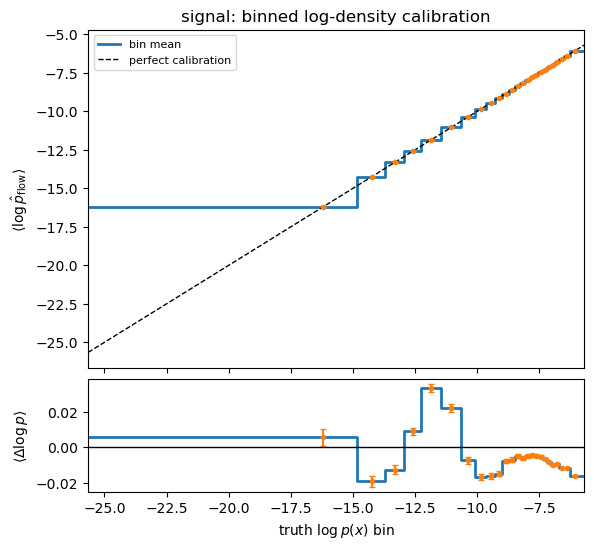

In [13]:
fig, background_logp_calibration = compare_log_density_to_truth_binned(
    "background", background_eval, flows["background"]
)
fig.savefig(
    PLOT_DIR / "background_flow_logp_truth_binned_calibration.pdf",
    bbox_inches="tight",
)
plt.show()

fig, signal_logp_calibration = compare_log_density_to_truth_binned(
    "signal", signal_eval, flows["signal"]
)
fig.savefig(
    PLOT_DIR / "signal_flow_logp_truth_binned_calibration.pdf",
    bbox_inches="tight",
)
plt.show()

## Direct likelihood from the learned densities

Because the flows estimate $p_\mathrm{sig}(x)$ and $p_\mathrm{bkg}(x)$ directly, we do **not** need to choose a reference density and we do **not** need to calculate ratios.

For a direct extended unbinned likelihood, define the event intensity

$$
\nu(x \mid \mu) = \mu\,\lambda_\mathrm{sig}\,\hat p_\mathrm{sig}(x)
+ \lambda_\mathrm{bkg}\,\hat p_\mathrm{bkg}(x).
$$

Dropping constants independent of $\mu$,

$$
-2\log L(\mu)
= -2 \sum_i w_i \log \nu(x_i\mid\mu)
+ 2\left(\mu\lambda_\mathrm{sig}+\lambda_\mathrm{bkg}\right).
$$

The code below stores `p_sig` and `p_bkg` as the yield-weighted terms
$\lambda_\mathrm{sig}\hat p_\mathrm{sig}(x_i)$ and
$\lambda_\mathrm{bkg}\hat p_\mathrm{bkg}(x_i)$, so the core likelihood line is just

```python
prob = mu * p_sig + p_bkg
```


In [14]:
asimov_dataset = pd.concat([background_eval, signal_eval], ignore_index=True).astype("float32").copy()
weights_asimov = np.asarray(asimov_dataset["weight"], dtype=np.float64)
X_asimov = asimov_dataset[FEATURES].to_numpy(dtype=np.float32)

lam_sig = float(TOTAL_YIELD["signal"])
lam_bkg = float(TOTAL_YIELD["background"])

log_p_sig_flow = flow_log_prob_x(flows["signal"], X_asimov)
log_p_bkg_flow = flow_log_prob_x(flows["background"], X_asimov)

In [15]:
def debug_likelihood_direction(p_sig_np, p_bkg_np, weights_np, lam_sig_value, labels_np=None):

    for mu in [0.0, 1.0, 3.0]:
        prob = mu * p_sig_np + p_bkg_np
        pull = weights_np * p_sig_np / np.maximum(prob, 1.0e-300)
        score = pull.sum() - lam_sig_value
        d_nll = -2.0 * score

        print(f"\nmu = {mu:g}")
        print(f"  sum w*s/(mu*s+b) = {pull.sum():.6g}")
        print(f"  target lambda_s   = {lam_sig_value:.6g}")
        print(f"  score             = {score:.6g}")
        print(f"  dNLL/dmu          = {d_nll:.6g}")

        if labels_np is not None:
            for lab, name in [(0, "background"), (1, "signal")]:
                mask = labels_np == lab
                if np.any(mask):
                    print(f"  contribution from {name:10s}: {pull[mask].sum():.6g}")

    ratio = p_sig_np / np.maximum(p_bkg_np, 1.0e-300)
    print("\nlog10(s/b) quantiles:")
    print(np.quantile(np.log10(np.maximum(ratio, 1.0e-300)), [0.0, 0.5, 0.9, 0.99, 0.999, 1.0]))


labels_asimov = asimov_dataset["label"].to_numpy() if "label" in asimov_dataset.columns else None



In [16]:
# Flow-based intensities
p_sig_flow_np = lam_sig * np.exp(np.clip(log_p_sig_flow, -745.0, 50.0))
p_bkg_flow_np = lam_bkg * np.exp(np.clip(log_p_bkg_flow, -745.0, 50.0))

# Truth-based intensities
log_p_sig_truth = mixture_log_density(X_asimov, TRUTH_RECO_COMPONENTS["signal"])
log_p_bkg_truth = mixture_log_density(X_asimov, TRUTH_RECO_COMPONENTS["background"])

p_sig_truth_np = lam_sig * np.exp(np.clip(log_p_sig_truth, -745.0, 50.0))
p_bkg_truth_np = lam_bkg * np.exp(np.clip(log_p_bkg_truth, -745.0, 50.0))

print("Flow likelihood direction:")
debug_likelihood_direction(
    p_sig_flow_np,
    p_bkg_flow_np,
    weights_asimov,
    lam_sig,
    labels_np=labels_asimov,
)

print("\nTruth likelihood direction:")
debug_likelihood_direction(
    p_sig_truth_np,
    p_bkg_truth_np,
    weights_asimov,
    lam_sig,
    labels_np=labels_asimov,
)

np.save(DENSITY_DIR / "p_sig_flow_asimov.npy", p_sig_flow_np)
np.save(DENSITY_DIR / "p_bkg_flow_asimov.npy", p_bkg_flow_np)
np.save(DENSITY_DIR / "weights_asimov.npy", weights_asimov)

print(f"Asimov events: {len(asimov_dataset):,}")
print(f"lambda_signal = {lam_sig:.6g}, lambda_background = {lam_bkg:.6g}")
print("\nYield-weighted flow-density ranges:")
for name, arr in [("signal", p_sig_flow_np), ("background", p_bkg_flow_np)]:
    print(f"  {name:10s}: min={arr.min():.4e}, median={np.median(arr):.4e}, max={arr.max():.4e}")

Flow likelihood direction:

mu = 0
  sum w*s/(mu*s+b) = 1199.23
  target lambda_s   = 1100
  score             = 99.2323
  dNLL/dmu          = -198.465
  contribution from background: 1195.12
  contribution from signal    : 4.11584

mu = 1
  sum w*s/(mu*s+b) = 1126.15
  target lambda_s   = 1100
  score             = 26.1483
  dNLL/dmu          = -52.2966
  contribution from background: 1122.08
  contribution from signal    : 4.07121

mu = 3
  sum w*s/(mu*s+b) = 1116.71
  target lambda_s   = 1100
  score             = 16.7063
  dNLL/dmu          = -33.4125
  contribution from background: 1112.72
  contribution from signal    : 3.99004

log10(s/b) quantiles:
[-6.26220751 -2.85360074 -2.29447262 -1.73854443 -1.3116177   2.22711921]

Truth likelihood direction:

mu = 0
  sum w*s/(mu*s+b) = 1106.33
  target lambda_s   = 1100
  score             = 6.32791
  dNLL/dmu          = -12.6558
  contribution from background: 1102.48
  contribution from signal    : 3.84431

mu = 1
  sum w*s/(mu*s+b) 

## Fit $\mu$ with a manual JAX likelihood

This is intentionally small: the normalizing flows provide the event densities, and JAX provides the gradient of the likelihood.

In [17]:
p_sig = jnp.asarray(p_sig_flow_np, dtype=jnp.float64)
p_bkg = jnp.asarray(p_bkg_flow_np, dtype=jnp.float64)
weights = jnp.asarray(weights_asimov, dtype=jnp.float64)
EPS = 1.0e-300


def nll_manual(params):
    mu = params[0]
    prob = mu * p_sig + p_bkg
    n_expected = mu * lam_sig + lam_bkg

    # The maximum protects the log.  The final where() enforces the physical
    # region and keeps the optimizer away from invalid negative intensities.
    nll = -2.0 * jnp.sum(weights * jnp.log(jnp.maximum(prob, EPS))) + 2.0 * n_expected
    invalid = (mu < 0.0) | (n_expected <= 0.0) | jnp.any(prob <= 0.0)
    return jnp.where(invalid, 1.0e30, nll)
    
inf_manual = nsbi_common_utils.inference.inference(
    model_nll=jax.jit(nll_manual),
    initial_values=[1.0],
    list_parameters=["mu"],
    num_unconstrained_params=1,
    model_grad=jax.jit(jax.grad(nll_manual)),  # analytic gradient, for free
)

print("\n" + "=" * 40)
print(" DIRECT FLOW-DENSITY FIT RESULTS ")
print("=" * 40 + "\n")
inf_manual.perform_fit(freeze_params=[])



 DIRECT FLOW-DENSITY FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -6.003e+06                 │         Nfcn = 25, Ngrad = 2         │
│ EDM = 3.27e-07 (Goal: 0.0002)    │            time = 5.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬─────────

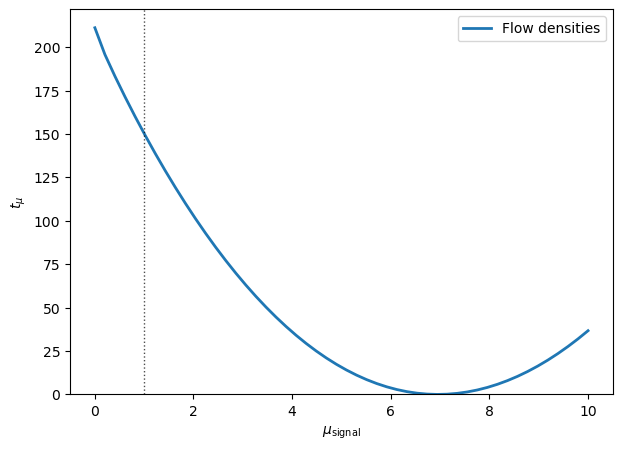

In [25]:
SCAN_RANGE = (0.0, 10.0)
scan_flow, tmu_flow = inf_manual.perform_profile_scan(
    parameter_name="mu",
    freeze_params=[],
    bound_range=SCAN_RANGE,
    fit_strategy=0,
    size=50,
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(scan_flow, tmu_flow, lw=2, label="Flow densities")
ax.axvline(1.0, color="black", ls=":", lw=1, alpha=0.7)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"$\mu_\mathrm{signal}$")
ax.set_ylabel(r"$t_\mu$")
ax.legend()
fig.savefig(PLOT_DIR / "flow_direct_density_tmu_scan.pdf", bbox_inches="tight")
plt.show()



 ANALYTIC RECO-DENSITY FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -6.016e+06                 │         Nfcn = 20, Ngrad = 1         │
│ EDM = 3.47e-05 (Goal: 0.0002)    │            time = 2.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬───────

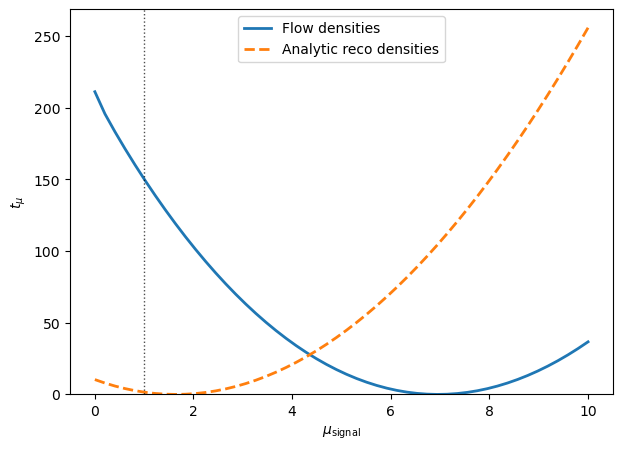

In [26]:
def make_direct_density_nll(p_sig_np, p_bkg_np, weights_np, lam_sig_value, lam_bkg_value):
    p_sig_j = jnp.asarray(p_sig_np, dtype=jnp.float64)
    p_bkg_j = jnp.asarray(p_bkg_np, dtype=jnp.float64)
    weights_j = jnp.asarray(weights_np, dtype=jnp.float64)
    lam_sig_value = float(lam_sig_value)
    lam_bkg_value = float(lam_bkg_value)

    def _nll(params):
        mu = params[0]
        prob = mu * p_sig_j + p_bkg_j
        n_expected = mu * lam_sig_value + lam_bkg_value
        nll = -2.0 * jnp.sum(weights_j * jnp.log(jnp.maximum(prob, EPS))) + 2.0 * n_expected
        invalid = (mu < 0.0) | (n_expected <= 0.0) | jnp.any(prob <= 0.0)
        return jnp.where(invalid, 1.0e30 + 1.0e12 * (mu - 1.0) ** 2, nll)

    return _nll


log_p_sig_truth = mixture_log_density(X_asimov, TRUTH_RECO_COMPONENTS["signal"])
log_p_bkg_truth = mixture_log_density(X_asimov, TRUTH_RECO_COMPONENTS["background"])

p_sig_truth_np = lam_sig * np.exp(np.clip(log_p_sig_truth, -745.0, 50.0))
p_bkg_truth_np = lam_bkg * np.exp(np.clip(log_p_bkg_truth, -745.0, 50.0))

nll_truth = make_direct_density_nll(
    p_sig_truth_np,
    p_bkg_truth_np,
    weights_asimov,
    lam_sig,
    lam_bkg,
)

inf_truth = nsbi_common_utils.inference.inference(
    model_nll=jax.jit(nll_truth),
    initial_values=[1.0],
    list_parameters=["mu"],
    num_unconstrained_params=1,
    model_grad=jax.jit(jax.grad(nll_truth)),
)

print("\n" + "=" * 40)
print(" ANALYTIC RECO-DENSITY FIT RESULTS ")
print("=" * 40 + "\n")
inf_truth.perform_fit(freeze_params=[])

scan_truth, tmu_truth = inf_truth.perform_profile_scan(
    parameter_name="mu",
    freeze_params=[],
    bound_range=SCAN_RANGE,
    fit_strategy=0,
    size=50,
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(scan_flow, tmu_flow, lw=2, label="Flow densities")
ax.plot(scan_truth, tmu_truth, lw=2, ls="--", label="Analytic reco densities")
ax.axvline(1.0, color="black", ls=":", lw=1, alpha=0.7)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"$\mu_\mathrm{signal}$")
ax.set_ylabel(r"$t_\mu$")
ax.legend()
fig.savefig(PLOT_DIR / "flow_vs_truth_direct_density_tmu_scan.pdf", bbox_inches="tight")
plt.show()


## Suggested exercises

1. Remove the extended-rate term from `nll_manual` and compare the behavior of the fit with the full extended likelihood.
2. Swap RealNVP for another flow, such as rational-quadratic splines, and compare the validation plots.
3. Train on truth-level `y*` variables instead of reco-level `x*` variables and compare how detector smearing changes the achievable sensitivity.
